<a href="https://colab.research.google.com/github/NewbieHocIT/HocMay/blob/main/Code_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Đọc đữ liệu


In [ ]:
from google.colab import drive
drive.mount('/content/drive',force_remount=True)

Mounted at /content/drive


In [ ]:
!unzip -q "/content/drive/MyDrive/Bigdata/phuongtien.zip" -d "/content"

output/Xe hơi/:  mismatching "local" filename (output/Xe h╞бi/),
         continuing with "central" filename version
output/Xe hơi/0.jpg:  mismatching "local" filename (output/Xe h╞бi/0.jpg),
         continuing with "central" filename version
output/Xe hơi/1.jpg:  mismatching "local" filename (output/Xe h╞бi/1.jpg),
         continuing with "central" filename version
output/Xe hơi/10.jpg:  mismatching "local" filename (output/Xe h╞бi/10.jpg),
         continuing with "central" filename version
output/Xe hơi/100.jpg:  mismatching "local" filename (output/Xe h╞бi/100.jpg),
         continuing with "central" filename version
output/Xe hơi/101.jpg:  mismatching "local" filename (output/Xe h╞бi/101.jpg),
         continuing with "central" filename version
output/Xe hơi/102.jpg:  mismatching "local" filename (output/Xe h╞бi/102.jpg),
         continuing with "central" filename version
output/Xe hơi/103.jpg:  mismatching "local" filename (output/Xe h╞бi/103.jpg),
         continuing with "ce

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import cv2
from sklearn.model_selection import train_test_split
from keras.models import Sequential
from keras.layers import Dense, Dropout, Activation, Flatten
from keras.layers import Convolution2D, MaxPooling2D
from keras.utils import to_categorical

# Gán nhãn

In [ ]:
path = '/content/output/'

categories = ['Máy bay', 'Xe hơi', 'Xe máy', 'Xe đạp', 'Xích lô']

# Xử lí ảnh

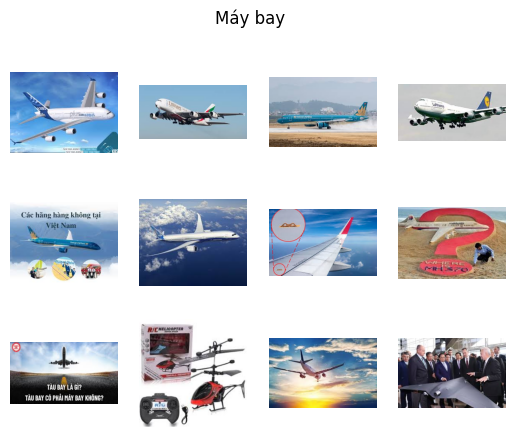

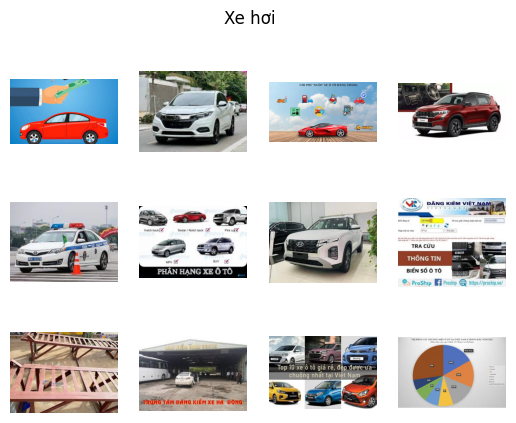

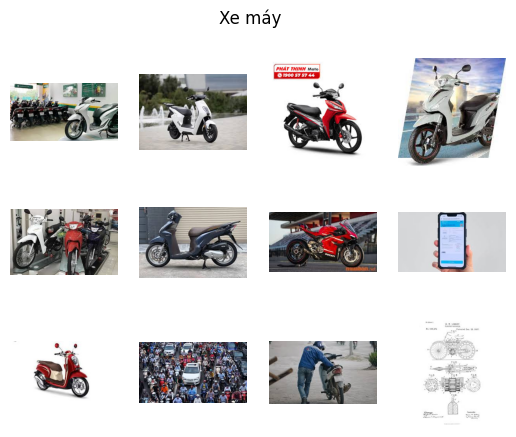

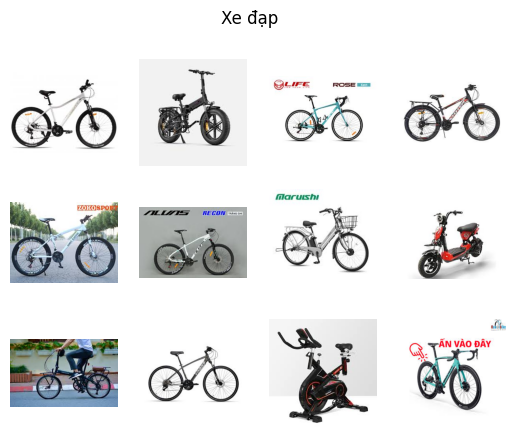

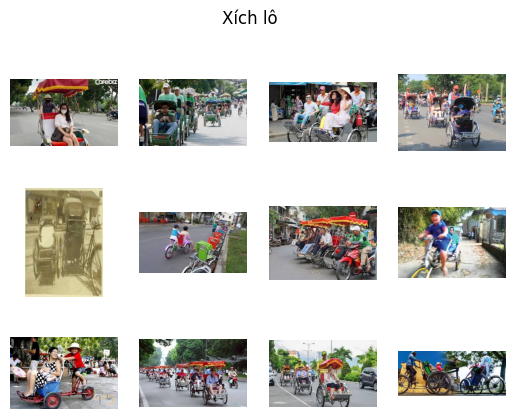

In [ ]:
for category in categories:
    fig, _ = plt.subplots(3,4)
    fig.suptitle(category)
    for k, v in enumerate(os.listdir(path+category)[:12]):
        img = plt.imread(path+category+'/'+v)
        plt.subplot(3, 4, k+1)
        plt.axis('off')
        plt.imshow(img)
    plt.show()

/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 7841 (\N{LATIN SMALL LETTER A WITH DOT BELOW}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 417 (\N{LATIN SMALL LETTER O WITH HORN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


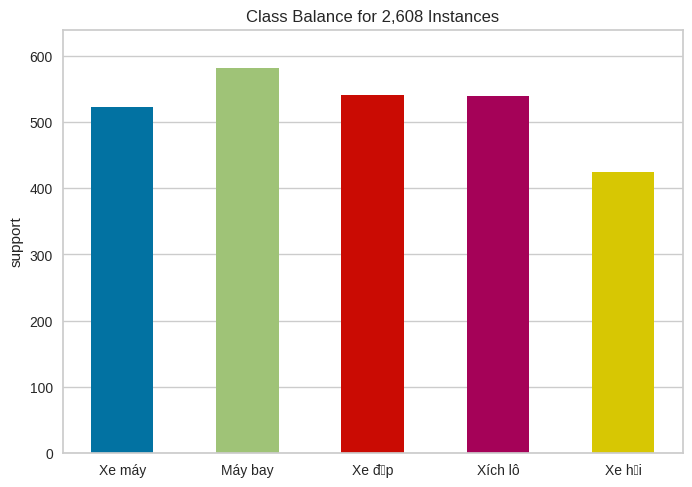

<Axes: title={'center': 'Class Balance for 2,608 Instances'}, ylabel='support'>

In [ ]:
import os
import numpy as np
from yellowbrick.target import ClassBalance

# Đường dẫn đến thư mục chứa ảnh (các thư mục con là tên các lớp)
image_dir = "/content/output/"

# Danh sách nhãn (lớp) từ tên các thư mục con
labels = [d for d in os.listdir(image_dir) if os.path.isdir(os.path.join(image_dir, d))]

# Tạo danh sách nhãn thực tế cho tất cả ảnh
y_train = []
for label in labels:
    class_dir = os.path.join(image_dir, label)
    num_images = len(os.listdir(class_dir))  # Đếm số lượng ảnh trong thư mục
    y_train.extend([label] * num_images)  # Thêm nhãn cho từng ảnh

# Convert y_train to a NumPy array
y_train = np.array(y_train)

# Hiển thị biểu đồ phân bố số lượng ảnh trong từng lớp
visualizer = ClassBalance(labels=labels)
visualizer.fit(y_train)
visualizer.show()  # Sử dụng show() thay vì poof()

In [ ]:
shape0 = []
shape1 = []

for category in categories:
    for files in os.listdir(path+category):
        shape0.append(plt.imread(path+category+'/'+ files).shape[0])
        shape1.append(plt.imread(path+category+'/'+ files).shape[1])
    print(category, ' => height min : ', min(shape0), 'width min : ', min(shape1))
    print(category, ' => height max : ', max(shape0), 'width max : ', max(shape1))
    shape0 = []
    shape1 = []

Máy bay  => height min :  112 width min :  154
Máy bay  => height max :  326 width max :  449
Xe hơi  => height min :  123 width min :  33
Xe hơi  => height max :  400 width max :  410
Xe máy  => height min :  117 width min :  176
Xe máy  => height max :  287 width max :  432
Xe đạp  => height min :  125 width min :  152
Xe đạp  => height max :  332 width max :  402
Xích lô  => height min :  142 width min :  150
Xích lô  => height max :  335 width max :  354


In [ ]:
data = []
labels = []
imagePaths = []
HEIGHT = 112
WIDTH = 112
N_CHANNELS = 3

# lấy các đường dẫn hình ảnh và trộn ngẫu nhiên để tránh lệch nhãn khi huấn luyện mô hình.
for k, category in enumerate(categories):
    for f in os.listdir(path+category):
        imagePaths.append([path+category+'/'+f, k]) # k=0 : 'máy bay', k=1 : 'xe hơi', k=2 : 'xe máy, k=3: xe đạp, k=4: xe xich lô'

import random
random.shuffle(imagePaths)
print(imagePaths[:10],'\n')
#đọc và xử lí ảnh  resize về kích thước cố định
for imagePath in imagePaths:
    image = cv2.imread(imagePath[0])
    image = cv2.resize(image, (WIDTH, HEIGHT))
    data.append(image)

    label = imagePath[1]
    labels.append(label)

[['/content/output/Xe đạp/27.jpg', 3], ['/content/output/Xe máy/92.jpg', 2], ['/content/output/Máy bay/607.jpg', 0], ['/content/output/Xe hơi/67.jpg', 1], ['/content/output/Xe đạp/178.jpg', 3], ['/content/output/Máy bay/379.jpg', 0], ['/content/output/Xe hơi/509.jpg', 1], ['/content/output/Máy bay/492.jpg', 0], ['/content/output/Xe máy/421.jpg', 2], ['/content/output/Xe máy/590.jpg', 2]] 



In [ ]:
data = np.array(data, dtype="float") / 255.0
labels = np.array(labels)

In [ ]:
print(labels)

[3 2 0 ... 3 3 2]


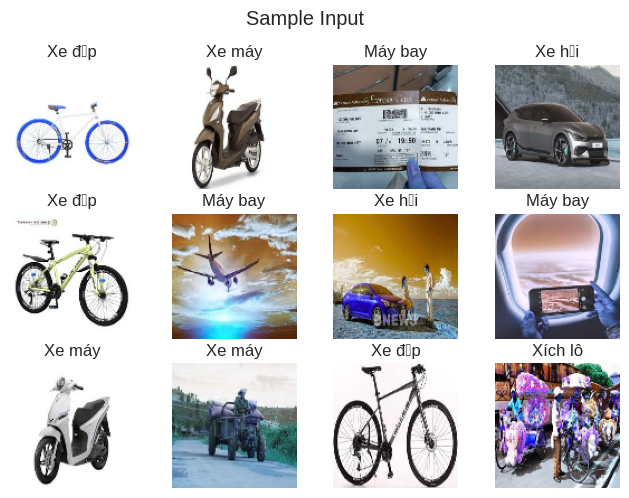

In [ ]:
fig, _ = plt.subplots(3,4)
fig.suptitle("Sample Input")
for i in range(12):
    plt.subplot(3,4, i+1)
    plt.imshow(data[i])
    plt.axis('off')
    plt.title(categories[labels[i]])
plt.show()

In [ ]:
!pip install np_utils

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 1.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for np_utils: filename=np_utils-0.6.0-py3-none-any.whl size=56437 sha256=c4b5be9fffe95050903a9c13dcfe438374b620b75f539d5b9e0b295d20df5fa2
  Stored in directory: /root/.cache/pip/wheels/b6/c7/50/2307607f44366dd021209f660045f8d51cb976514d30be7cc7
Successfully built np_utils


# HUấn luyện mô hình với CNN

In [ ]:
(trainX, testX, trainY, testY) = train_test_split(data, labels, test_size=0.2, random_state=42)
trainY = to_categorical(trainY, 5)
trainX = np.array(trainX)
testX = np.array(testX)
trainY = np.array(trainY)
testY = np.array(testY)
testY = to_categorical(testY, 5)

print(trainX.shape)
print(testX.shape)
print(trainY.shape)
print(testY.shape)

(2086, 112, 112, 3)
(522, 112, 112, 3)
(2086, 5)
(522, 5)


In [ ]:
# Libraries to create and train our model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import Callback
from tensorflow.keras import models, layers, Model
from keras.callbacks import ModelCheckpoint
import time
import tensorflow as tf
from sklearn.metrics import accuracy_score

In [ ]:
# Hàm callback để dừng huấn luyện khi đạt được độ chính xác mong muốn
class AccuracyCallback(Callback):
    def __init__(self, target_accuracy):
        super(AccuracyCallback, self).__init__()
        self.target_accuracy = target_accuracy
        self.start_time = None

    def on_epoch_begin(self, epoch, logs=None):
        if self.start_time is None:
            self.start_time = time.time()

    def on_epoch_end(self, epoch, logs=None):
        current_accuracy = logs.get('val_accuracy') or logs.get('val_acc')
        if current_accuracy >= self.target_accuracy:
            end_time = time.time()
            total_time = end_time - self.start_time
            print(f"Target accuracy reached! Total training time: {total_time:.2f} seconds")

# Viết callback để tìm ra độ chính xác cao nhất đối với mô hình
class HighAccuracyCallback(Callback):
    def __init__(self):
        super(HighAccuracyCallback, self).__init__()
        self.highest_accuracy = 0.0

    def on_epoch_end(self, epoch, logs=None):
        current_accuracy = logs.get('val_accuracy')
        if current_accuracy is not None and current_accuracy > self.highest_accuracy:
            self.highest_accuracy = current_accuracy
            print(f"Highest accuracy achieved: {current_accuracy:.4f} at epoch {epoch + 1}")

# Sử dụng callback trong quá trình biên soạn mô hình
callback = HighAccuracyCallback()

# Khởi tạo callback với độ chính xác mục tiêu là 0.70 (79%)
accuracy_callback = AccuracyCallback(target_accuracy=0.79)

In [ ]:
model = Sequential()

model.add(Convolution2D(32, (2, 2), activation='relu', input_shape=(HEIGHT, WIDTH, N_CHANNELS)))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Convolution2D(32, (2, 2), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Dropout(0.25)) #tránh tình trạng overfiting

model.add(Convolution2D(32, (2, 2), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Convolution2D(32, (2, 2), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Dropout(0.25))

model.add(Flatten()) #trải dài outoput
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(5, activation='softmax')) #lớp dự đoán kết quả dự đoán vecto 5 phần tử

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

print(model.summary())

/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 111, 111, 32)        │             416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 55, 55, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 54, 54, 32)          │           4,128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 27, 27, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 27, 27, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 26, 26, 32)          │           4,128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 12, 12, 32)          │           4,128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 6, 6, 32)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 6, 6, 32)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 1152)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 5)                   │             645 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 161,029 (629.02 KB)

 Trainable params: 161,029 (629.02 KB)

 Non-trainable params: 0 (0.00 B)

None


In [ ]:
start_time = time.time()

# Khởi tạo callback với độ chính xác mục tiêu là 0.70 (79%)
accuracy_callback = AccuracyCallback(target_accuracy=0.69)

# Sử dụng callback trong quá trình biên soạn mô hình
callback = HighAccuracyCallback()
cnn_adam = model.fit(trainX, trainY, batch_size=32, epochs=20, verbose=1, validation_data=(testX,testY), callbacks=[accuracy_callback, callback])

# Kết thúc tính thời gian
end_time = time.time()
# Tính tổng thời gian chạy huấn luyện
total_time = end_time - start_time
print(f"Total training time: {total_time} seconds")

Epoch 1/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 599ms/step - accuracy: 0.2099 - loss: 1.6267Highest accuracy achieved: 0.2490 at epoch 1
66/66 ━━━━━━━━━━━━━━━━━━━━ 44s 628ms/step - accuracy: 0.2100 - loss: 1.6264 - val_accuracy: 0.2490 - val_loss: 1.5947
Epoch 2/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 390ms/step - accuracy: 0.2618 - loss: 1.5686Highest accuracy achieved: 0.4368 at epoch 2
66/66 ━━━━━━━━━━━━━━━━━━━━ 68s 415ms/step - accuracy: 0.2625 - loss: 1.5678 - val_accuracy: 0.4368 - val_loss: 1.3832
Epoch 3/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 404ms/step - accuracy: 0.4482 - loss: 1.3400Highest accuracy achieved: 0.4981 at epoch 3
66/66 ━━━━━━━━━━━━━━━━━━━━ 42s 428ms/step - accuracy: 0.4487 - loss: 1.3393 - val_accuracy: 0.4981 - val_loss: 1.2523
Epoch 4/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 372ms/step - accuracy: 0.5521 - loss: 1.1721Highest accuracy achieved: 0.5268 at epoch 4
66/66 ━━━━━━━━━━━━━━━━━━━━ 40s 416ms/step - accuracy: 0.5517 - loss: 1.1724 - val_accuracy: 0.5268 - val_loss: 1.1717
Epoch 5/

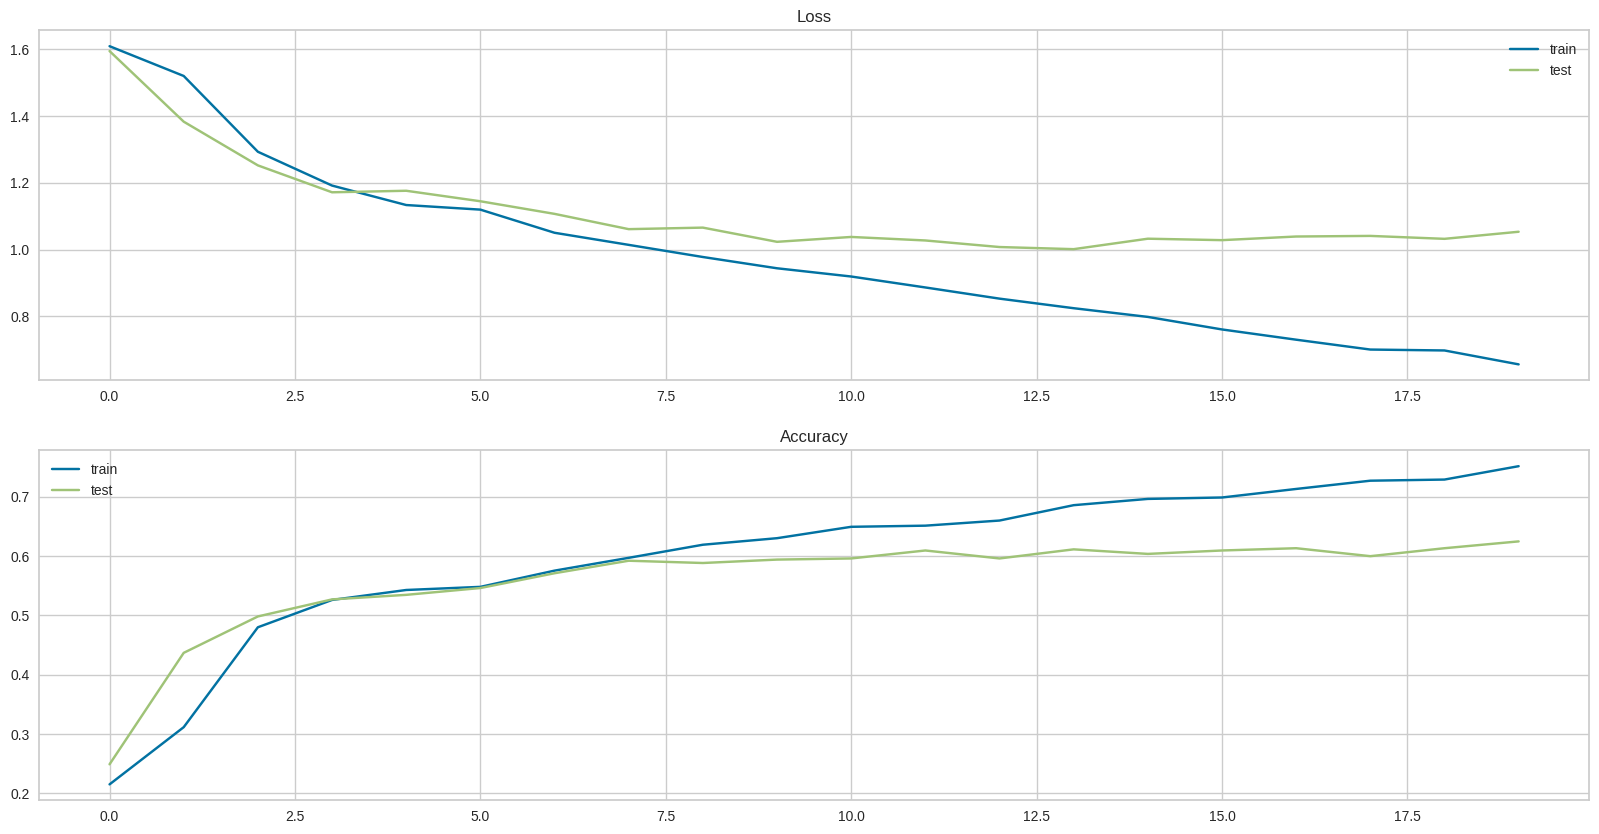

In [ ]:
import matplotlib.pyplot as pyplot

pyplot.figure(figsize=(20,10))
pyplot.subplot(211)
pyplot.title('Loss')
pyplot.plot(cnn_adam.history['loss'], label='train')
pyplot.plot(cnn_adam.history['val_loss'], label='test')
pyplot.legend()
# plot accuracy during training
pyplot.subplot(212)
pyplot.title('Accuracy')
pyplot.plot(cnn_adam.history['accuracy'], label='train')
pyplot.plot(cnn_adam.history['val_accuracy'], label='test')
pyplot.legend()
pyplot.show()

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

def truc_quan_kq(y_test, y_pred_knn):
  conf_matrix = confusion_matrix(y_true=y_test, y_pred=y_pred_knn)
  #sử dụng Matplotlib để vẽ confusion matrix
  fig, ax = plt.subplots(figsize=(5, 5))
  cax = ax.matshow(conf_matrix, cmap=plt.cm.Oranges, alpha=0.3)

  for i in range(conf_matrix.shape[0]):
      for j in range(conf_matrix.shape[1]):
          ax.text(x=j, y=i,s=conf_matrix[i, j], va='center', ha='center', size='xx-large')
  fig.colorbar(cax)
  plt.xlabel('Dự đoán', fontsize=18)
  plt.ylabel('Label', fontsize=18)
  plt.title('Confusion Matrix', fontsize=18)
  plt.show()

17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 110ms/step


/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 7921 (\N{LATIN SMALL LETTER U WITH HORN AND DOT BELOW}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


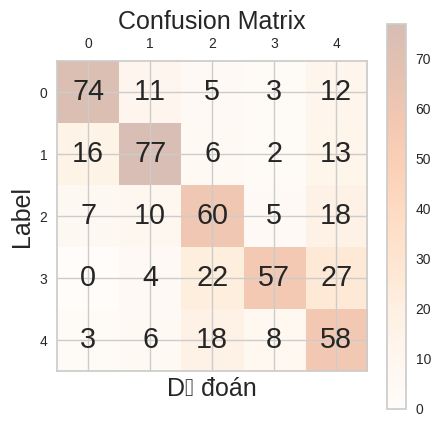

ValueError: Classification metrics can't handle a mix of multilabel-indicator and multiclass targets

In [ ]:
from numpy import argmax
from sklearn.metrics import confusion_matrix, accuracy_score
%matplotlib inline


pred = model.predict(testX)
predictions = argmax(pred, axis = 1)
testY_1d = argmax(testY, axis = 1)

truc_quan_kq(testY_1d, predictions)


accuracy = accuracy_score(testY, predictions)
print("Accuracy : %.2f%%" % (accuracy*100.0))

In [ ]:
from sklearn.metrics import classification_report
from numpy import argmax

# Chuyển testY từ one-hot encoding sang chỉ số lớp
testY_labels = argmax(testY, axis=1)

# In báo cáo phân loại
categories = ['Máy bay', 'Xe hơi', 'Xe máy', 'Xe đạp', 'Xích lô']
print(classification_report(testY_labels, predictions, target_names=categories))


              precision    recall  f1-score   support

     Máy bay       0.74      0.70      0.72       105
      Xe hơi       0.71      0.68      0.69       114
      Xe máy       0.54      0.60      0.57       100
      Xe đạp       0.76      0.52      0.62       110
     Xích lô       0.45      0.62      0.52        93

    accuracy                           0.62       522
   macro avg       0.64      0.62      0.63       522
weighted avg       0.65      0.62      0.63       522



# Kiểm thử với 1 số ảnh

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
Prediction : Máy bay


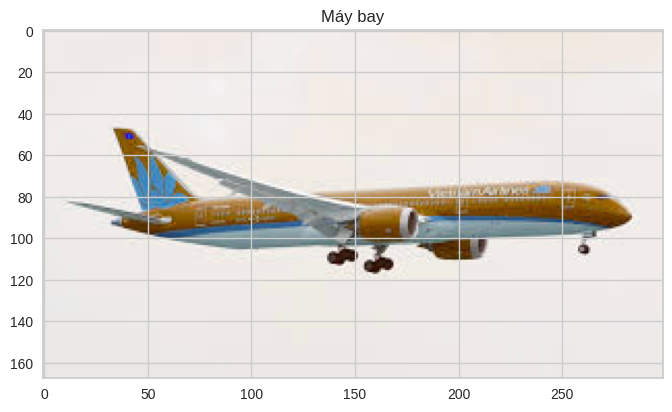

In [ ]:
from PIL import Image
import cv2


test_data=[]
test_image_o = cv2.imread('/content/drive/MyDrive/Bigdata/May_bay.jpg')
test_image = cv2.resize(test_image_o, (WIDTH, HEIGHT))  # .flatten()
test_data.append(test_image)

test_data = np.array(test_image, dtype="float") / 255.0
test_data=test_data.reshape([-1,112, 112, 3])
pred = model.predict(test_data)
predictions = argmax(pred, axis=1) # return to label
print ('Prediction : '+categories[predictions[0]])

fig = plt.figure()
plt.title(categories[predictions[0]])

plt.imshow(test_image_o)

In [ ]:
transports = ['Máy bay', 'Xe hơi', 'Xe máy', 'Xe đạp', 'Xích lô']
for idx, animal, x in zip(range(0,5), transports , pred[0]):
    print("ID: {}, Label: {} {}%".format(idx, animal, round(x*100,2) ))
print ('Prediction : '+transports[predictions[0]])

ID: 0, Label: Máy bay 99.07%
ID: 1, Label: Xe hơi 0.86%
ID: 2, Label: Xe máy 0.02%
ID: 3, Label: Xe đạp 0.01%
ID: 4, Label: Xích lô 0.03%
Prediction : Máy bay


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
Prediction : Xích lô


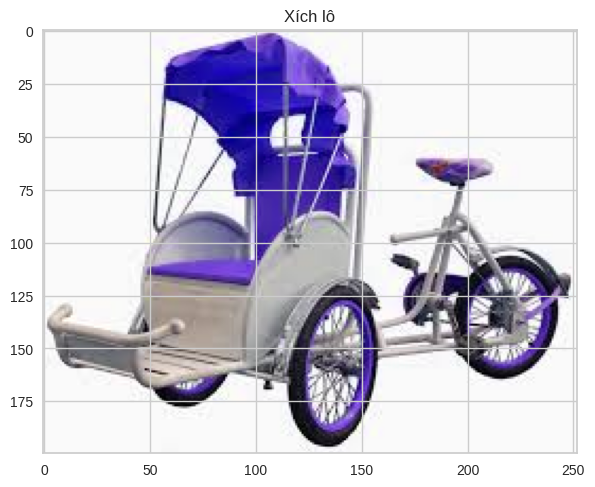

In [ ]:
from PIL import Image
import cv2


test_data=[]
test_image_o = cv2.imread('/content/drive/MyDrive/Bigdata/Xich_lo.jpg')
test_image = cv2.resize(test_image_o, (WIDTH, HEIGHT))  # .flatten()
test_data.append(test_image)

test_data = np.array(test_image, dtype="float") / 255.0
test_data=test_data.reshape([-1,112, 112, 3])
pred = model.predict(test_data)
predictions = argmax(pred, axis=1) # return to label
print ('Prediction : '+categories[predictions[0]])

fig = plt.figure()
plt.title(categories[predictions[0]])

plt.imshow(test_image_o)

In [ ]:
transports = ['Máy bay', 'Xe hơi', 'Xe máy', 'Xe đạp', 'Xích lô']
for idx, animal, x in zip(range(0,5), transports , pred[0]):
    print("ID: {}, Label: {} {}%".format(idx, animal, round(x*100,2) ))
print ('Prediction : '+transports[predictions[0]])

ID: 0, Label: Máy bay 0.42%
ID: 1, Label: Xe hơi 1.49%
ID: 2, Label: Xe máy 9.44%
ID: 3, Label: Xe đạp 13.07%
ID: 4, Label: Xích lô 75.59%
Prediction : Xích lô


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
Prediction : Xe hơi


/usr/local/lib/python3.10/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 417 (\N{LATIN SMALL LETTER O WITH HORN}) missing from current font.
  func(*args, **kwargs)
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 417 (\N{LATIN SMALL LETTER O WITH HORN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


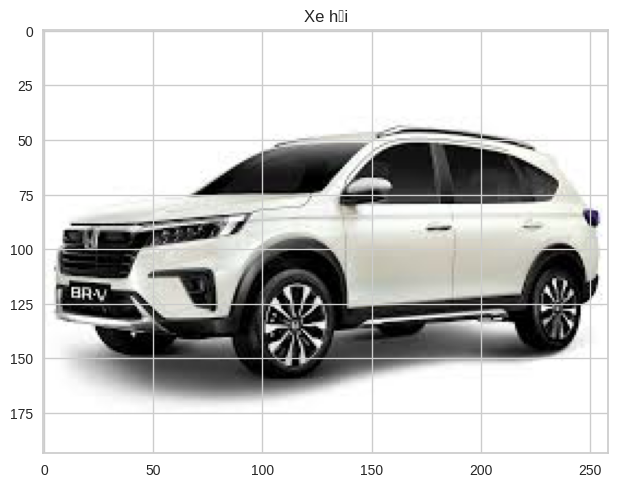

In [ ]:
test_data=[]
input = ('/content/drive/MyDrive/Bigdata/oto.jpg') #@param {type:"string"}
test_image_o = cv2.imread(input)
test_image = cv2.resize(test_image_o, (WIDTH, HEIGHT))  # .flatten()
test_data.append(test_image)

test_data = np.array(test_image, dtype="float") / 255.0
test_data=test_data.reshape([-1,112, 112, 3])
pred = model.predict(test_data)
predictions = argmax(pred, axis=1) # return to label
print ('Prediction : '+categories[predictions[0]])

fig = plt.figure()
plt.title(categories[predictions[0]])

plt.imshow(test_image_o)

In [ ]:
transports = ['Máy bay', 'Xe hơi', 'Xe máy', 'Xe đạp', 'Xích lô']
for idx, animal, x in zip(range(0,5), transports , pred[0]):
    print("ID: {}, Label: {} {}%".format(idx, animal, round(x*100,2) ))
print ('Prediction : '+transports[predictions[0]])

ID: 0, Label: Máy bay 0.0%
ID: 1, Label: Xe hơi 99.98%
ID: 2, Label: Xe máy 0.01%
ID: 3, Label: Xe đạp 0.0%
ID: 4, Label: Xích lô 0.0%
Prediction : Xe hơi


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
Prediction : Xe đạp


/usr/local/lib/python3.10/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 7841 (\N{LATIN SMALL LETTER A WITH DOT BELOW}) missing from current font.
  func(*args, **kwargs)
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 7841 (\N{LATIN SMALL LETTER A WITH DOT BELOW}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


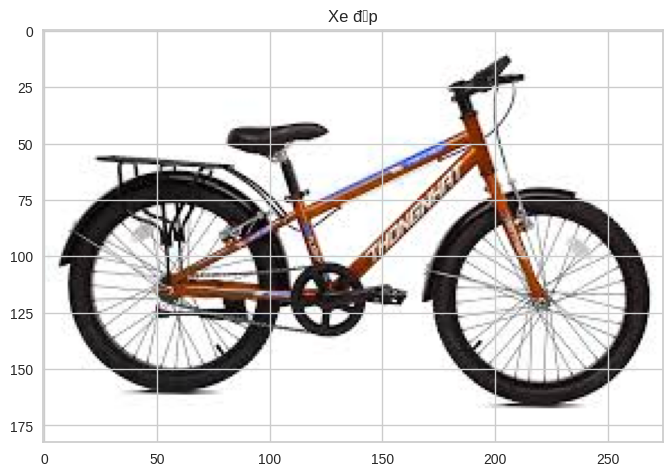

In [ ]:
test_data=[]
input = ('/content/drive/MyDrive/Bigdata/Xe_Dap.jpg') #@param {type:"string"}
test_image_o = cv2.imread(input)
test_image = cv2.resize(test_image_o, (WIDTH, HEIGHT))  # .flatten()
test_data.append(test_image)

test_data = np.array(test_image, dtype="float") / 255.0
test_data=test_data.reshape([-1,112, 112, 3])
pred = model.predict(test_data)
predictions = argmax(pred, axis=1) # return to label
print ('Prediction : '+categories[predictions[0]])

fig = plt.figure()
plt.title(categories[predictions[0]])

plt.imshow(test_image_o)

In [ ]:
transports = ['Máy bay', 'Xe hơi', 'Xe máy', 'Xe đạp', 'Xích lô']
for idx, animal, x in zip(range(0,5), transports , pred[0]):
    print("ID: {}, Label: {} {}%".format(idx, animal, round(x*100,2) ))
print ('Prediction : '+transports[predictions[0]])

ID: 0, Label: Máy bay 0.0%
ID: 1, Label: Xe hơi 0.0%
ID: 2, Label: Xe máy 0.0%
ID: 3, Label: Xe đạp 100.0%
ID: 4, Label: Xích lô 0.0%
Prediction : Xe đạp


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Prediction : Xe máy


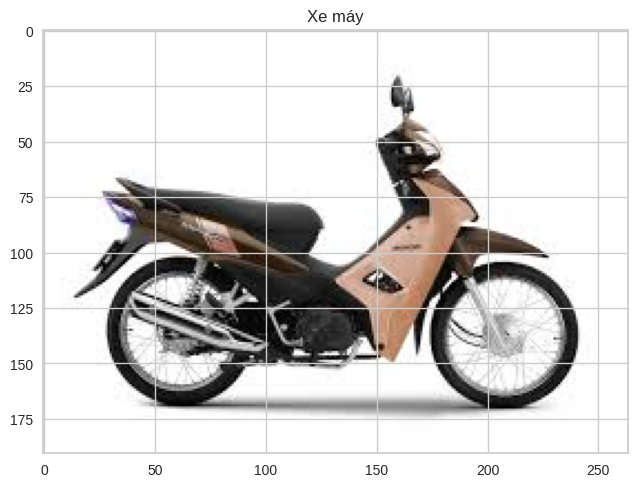

In [ ]:
test_data=[]
input = ('/content/drive/MyDrive/Bigdata/xe_may.jpg') #@param {type:"string"}
test_image_o = cv2.imread(input)
test_image = cv2.resize(test_image_o, (WIDTH, HEIGHT))  # .flatten()
test_data.append(test_image)

test_data = np.array(test_image, dtype="float") / 255.0
test_data=test_data.reshape([-1,112, 112, 3])
pred = model.predict(test_data)
predictions = argmax(pred, axis=1) # return to label
print ('Prediction : '+categories[predictions[0]])

fig = plt.figure()
plt.title(categories[predictions[0]])

plt.imshow(test_image_o)

In [ ]:
transports = ['Máy bay', 'Xe hơi', 'Xe máy', 'Xe đạp', 'Xích lô']
for idx, animal, x in zip(range(0,5), transports , pred[0]):
    print("ID: {}, Label: {} {}%".format(idx, animal, round(x*100,2) ))
print ('Prediction : '+transports[predictions[0]])

ID: 0, Label: Máy bay 0.0%
ID: 1, Label: Xe hơi 0.0%
ID: 2, Label: Xe máy 97.25%
ID: 3, Label: Xe đạp 2.74%
ID: 4, Label: Xích lô 0.01%
Prediction : Xe máy


# thử nghiệm với các mô hình khác ( K-Mean , hồi quy logitic,KNN)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report
from sklearn.cluster import KMeans

In [ ]:
label_to_id_dict = {v:i for i,v in enumerate(np.unique(categories))}
id_to_label_dict = {v: k for k, v in label_to_id_dict.items()}
print(label_to_id_dict, '\n========\n', id_to_label_dict)

{'Máy bay': 0, 'Xe hơi': 1, 'Xe máy': 2, 'Xe đạp': 3, 'Xích lô': 4} 
 {0: 'Máy bay', 1: 'Xe hơi', 2: 'Xe máy', 3: 'Xe đạp', 4: 'Xích lô'}


In [ ]:
data = np.array(data, dtype="float") / 255.0
labels = np.array(labels)

In [ ]:
# encode the labels as integer
label_ids = np.array(labels)

le = LabelEncoder()
label_ids = le.fit_transform(labels)

label_ids

array([3, 2, 0, ..., 3, 3, 2])

In [ ]:
dataset_size_train = data.shape[0]
data = data.reshape(dataset_size_train,-1)

In [ ]:
(trainX, testX, trainY, testY) = train_test_split(data, labels, test_size=0.2, random_state=42)
print(trainX.shape)
print(testX.shape)
print(trainY.shape)
print(testY.shape)

(2086, 37632)
(522, 37632)
(2086,)
(522,)


In [ ]:
model = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
model.fit(trainX, trainY)

print(classification_report(testY, model.predict(testX), target_names=categories))

              precision    recall  f1-score   support

     Máy bay       0.29      0.96      0.45       105
      Xe hơi       0.43      0.18      0.25       114
      Xe máy       0.44      0.24      0.31       100
      Xe đạp       0.50      0.17      0.26       110
     Xích lô       0.38      0.16      0.23        93

    accuracy                           0.34       522
   macro avg       0.41      0.34      0.30       522
weighted avg       0.41      0.34      0.30       522



/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 7921 (\N{LATIN SMALL LETTER U WITH HORN AND DOT BELOW}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


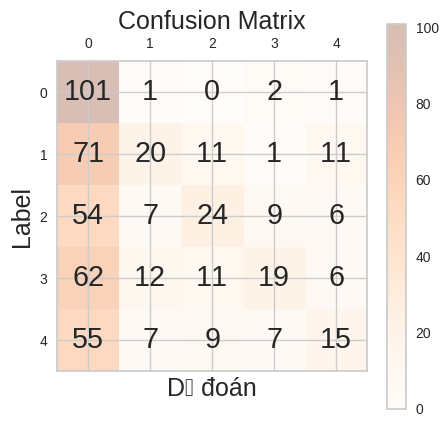

In [ ]:
truc_quan_kq(testY, model.predict(testX))

In [ ]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression(random_state=0)
clf.fit(trainX, trainY)

print(classification_report(testY, clf.predict(testX), target_names=categories))

              precision    recall  f1-score   support

     Máy bay       0.00      0.00      0.00       105
      Xe hơi       0.22      1.00      0.36       114
      Xe máy       0.00      0.00      0.00       100
      Xe đạp       0.00      0.00      0.00       110
     Xích lô       0.00      0.00      0.00        93

    accuracy                           0.22       522
   macro avg       0.04      0.20      0.07       522
weighted avg       0.05      0.22      0.08       522



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 7921 (\N{LATIN SMALL LETTER U WITH HORN AND DOT BELOW}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


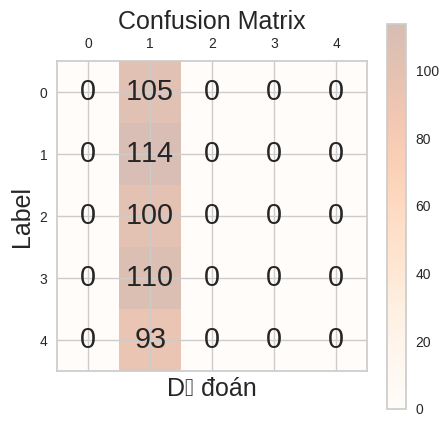

In [ ]:
truc_quan_kq(testY, clf.predict(testX))

In [ ]:
kmeans = KMeans(n_clusters=5, random_state=0, n_init="auto").fit(trainX)

print(classification_report(testY, kmeans.predict(testX), target_names=categories))

              precision    recall  f1-score   support

     Máy bay       0.20      0.23      0.21       105
      Xe hơi       0.18      0.18      0.18       114
      Xe máy       0.11      0.09      0.10       100
      Xe đạp       0.17      0.14      0.15       110
     Xích lô       0.29      0.40      0.34        93

    accuracy                           0.20       522
   macro avg       0.19      0.21      0.20       522
weighted avg       0.19      0.20      0.19       522



/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 7921 (\N{LATIN SMALL LETTER U WITH HORN AND DOT BELOW}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


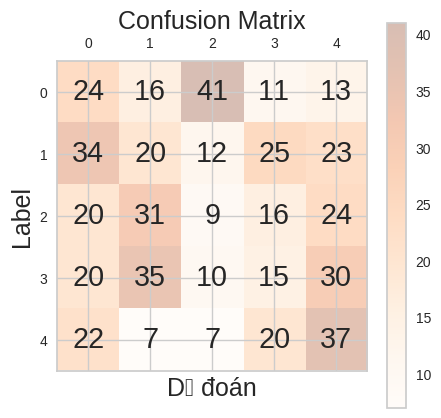

In [ ]:
truc_quan_kq(testY, kmeans.predict(testX))